In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from worldcup.tournament import load_teams, get_groups, get_group_matches
from worldcup.simulator import GroupStageSimulator
from worldcup.algorithms.poisson import PoissonGoalModel, _poisson_pmf
from worldcup.algorithms.scrabble import ScrabbleRatingModel, word_score, letters

sns.set_theme(style='whitegrid', palette='muted')

# ── Configure model here ──────────────────────────────────────────────────────
rating_model = ScrabbleRatingModel()
predictor = PoissonGoalModel(rating_model, base_lambda=1.3, alpha=0.3, max_ratio=10.0)
N_SIMULATIONS = 20_000
SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

teams = load_teams()
groups = get_groups(teams)
flag_map  = {t.name: t.flag  for t in teams}
group_map = {t.name: t.group for t in teams}

mens_rankings = pd.read_csv('../data/rankings.csv').set_index('country')

# Scrabble model

## Algorithm

This model rates each team by the **Scrabble score of its country name**, played on
a double word score square.

**Hypothesis:** does a country having a name full of high-value Scrabble tiles
(J, Q, X, Z...) predict footballing strength? (Spoiler: no — but Bosnia-Herzegovina
fans can dream.)

### Rating

Accents are stripped (Côte d'Ivoire → COTEDIVOIRE, Curaçao → CURACAO) and spaces,
hyphens and apostrophes are ignored. Each remaining letter scores its standard
English Scrabble tile value, and the word total is doubled for landing on a double
word score square:

$$\text{rating}(t) = 2 \times \sum_{\text{letter} \in \text{name}(t)} \text{tile\_value}(\text{letter})$$

| Value | Letters |
|---|---|
| 1 | A, E, I, L, N, O, R, S, T, U |
| 2 | D, G |
| 3 | B, C, M, P |
| 4 | F, H, V, W, Y |
| 5 | K |
| 8 | J, X |
| 10 | Q, Z |

The rating feeds into the Poisson goal model via the rating ratio **and its inverse**:
$$\lambda_h = \lambda_0 \cdot \text{ratio}^{\alpha}, \qquad \lambda_a = \frac{\lambda_0}{\text{ratio}^{\alpha}}, \qquad \text{ratio} = \frac{\text{rating}(\text{home})}{\text{rating}(\text{away})}$$
with $\lambda_0 = 1.3$, $\alpha = 0.3$, max ratio cap = 10.

### Component breakdown — all WC teams

In [2]:
rows = []
for t in sorted(teams, key=lambda t: rating_model.rate(t), reverse=True):
    name_letters = ''.join(letters(t.name))
    score = word_score(t.name)
    m_rank = int(mens_rankings.loc[t.name, 'fifa_ranking'])
    m_pts  = float(mens_rankings.loc[t.name, 'fifa_points'])
    rows.append({
        'Team':            f'{flag_map[t.name]} {t.name}',
        'Letters':         name_letters,
        'Word score':      score,
        'Double word score (rating)': 2 * score,
        "Men's FIFA rank": m_rank,
        "Men's FIFA pts":  round(m_pts, 1),
    })

breakdown = pd.DataFrame(rows)
breakdown.style \
    .hide(axis='index') \
    .background_gradient(subset='Double word score (rating)', cmap='RdYlGn', vmin=8, vmax=70) \
    .background_gradient(subset="Men's FIFA pts",              cmap='RdYlGn', vmin=700, vmax=1900)

Team,Letters,Word score,Double word score (rating),Men's FIFA rank,Men's FIFA pts
🇧🇦 Bosnia-Herzegovina,BOSNIAHERZEGOVINA,35,70,64,1387.200000
🇺🇿 Uzbekistan,UZBEKISTAN,25,50,50,1458.700000
🇨🇭 Switzerland,SWITZERLAND,24,48,19,1650.100000
🇨🇿 Czechia,CZECHIA,23,46,40,1505.700000
🇳🇿 New Zealand,NEWZEALAND,23,46,85,1275.600000
🇿🇦 South Africa,SOUTHAFRICA,19,38,60,1428.400000
🇨🇮 Ivory Coast,IVORYCOAST,18,36,33,1540.900000
🇲🇽 Mexico,MEXICO,17,34,14,1687.500000
🇰🇷 South Korea,SOUTHKOREA,17,34,25,1591.600000
🇧🇷 Brazil,BRAZIL,17,34,6,1765.900000


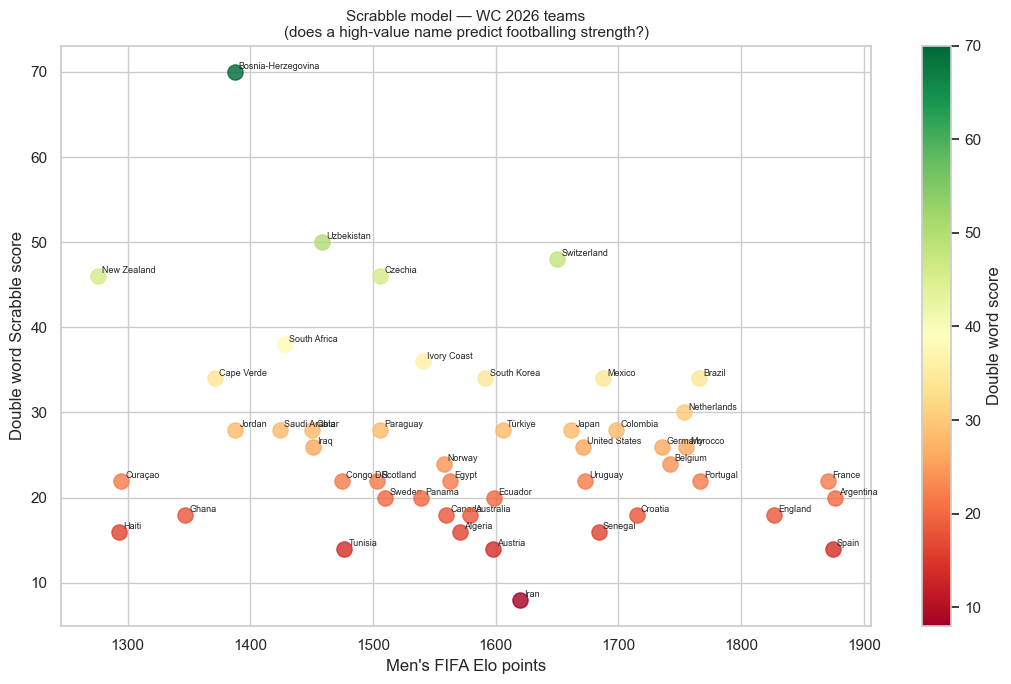

In [3]:
# Scatter: men's FIFA points vs double word score, colour = rating
fig, ax = plt.subplots(figsize=(11, 7))

scrabble_ratings = [rating_model.rate(t) for t in teams]
norm = plt.Normalize(min(scrabble_ratings), max(scrabble_ratings))
cmap = plt.cm.RdYlGn

for t in teams:
    m_pts = float(mens_rankings.loc[t.name, 'fifa_points'])
    rating = rating_model.rate(t)
    ax.scatter(m_pts, rating, s=120, alpha=0.8, color=cmap(norm(rating)), zorder=3)
    ax.annotate(t.name, (m_pts, rating), fontsize=6.5,
                xytext=(3, 2), textcoords='offset points')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Double word score')

ax.set_xlabel("Men's FIFA Elo points")
ax.set_ylabel('Double word Scrabble score')
ax.set_title('Scrabble model — WC 2026 teams\n(does a high-value name predict footballing strength?)', fontsize=11)
plt.tight_layout()
plt.show()

### Example prediction — Bosnia-Herzegovina vs Iran

Bosnia-Herzegovina: BOSNIAHERZEGOVINA -> word score 35, double word score 70
Iran: IRAN -> word score 4, double word score 8
λ_home = 2.492,  λ_away = 0.678


Outcome,Probability
🇧🇦 Bosnia-Herzegovina win,77.0%
Draw,14.9%
🇮🇷 Iran win,8.1%


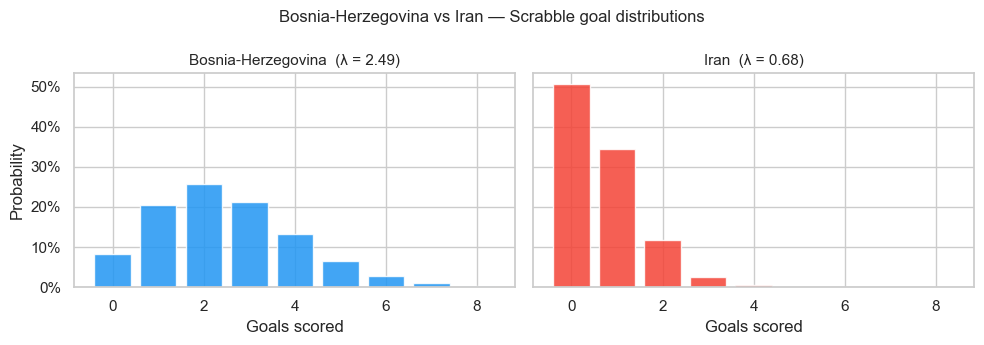

In [4]:
example_home = next(t for t in teams if t.name == 'Bosnia-Herzegovina')
example_away = next(t for t in teams if t.name == 'Iran')

score_h = word_score(example_home.name)
score_a = word_score(example_away.name)
λ_h, λ_a = predictor.lambdas(example_home, example_away)
p_home, p_draw, p_away = predictor.predict(example_home, example_away)

print(f"{example_home.name}: {''.join(letters(example_home.name))} -> word score {score_h}, double word score {2*score_h}")
print(f"{example_away.name}: {''.join(letters(example_away.name))} -> word score {score_a}, double word score {2*score_a}")
print(f'λ_home = {λ_h:.3f},  λ_away = {λ_a:.3f}')

example_df = pd.DataFrame([
    {'Outcome': f'{example_home.flag} {example_home.name} win', 'Probability': p_home},
    {'Outcome': 'Draw',                                          'Probability': p_draw},
    {'Outcome': f'{example_away.flag} {example_away.name} win', 'Probability': p_away},
])
display(example_df.style.hide(axis='index')
        .format({'Probability': '{:.1%}'})
        .bar(subset='Probability', color='#90CAF9', vmin=0, vmax=1))

max_g = 8
goals = np.arange(0, max_g + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].bar(goals, [_poisson_pmf(g, λ_h) for g in goals], color='#2196F3', alpha=0.85)
axes[0].set_title(f'{example_home.name}  (λ = {λ_h:.2f})', fontsize=11)
axes[0].set_xlabel('Goals scored'); axes[0].set_ylabel('Probability')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[1].bar(goals, [_poisson_pmf(g, λ_a) for g in goals], color='#F44336', alpha=0.85)
axes[1].set_title(f'{example_away.name}  (λ = {λ_a:.2f})', fontsize=11)
axes[1].set_xlabel('Goals scored')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
fig.suptitle(f'{example_home.name} vs {example_away.name} — Scrabble goal distributions', fontsize=12)
plt.tight_layout(); plt.show()

---

## Group stage qualification probabilities

In [5]:
sim = GroupStageSimulator(predictor, n=N_SIMULATIONS, seed=SEED)
results = sim.run(groups)
df = results.to_dataframe()

df['flag']     = df['team'].map(flag_map)
df['group']    = df['team'].map(group_map)
df['Team']     = df['flag'] + ' ' + df['team']
df['scrabble'] = df['team'].map(lambda n: rating_model.rate(next(t for t in teams if t.name == n)))

qual_table = df[['group', 'Team', 'scrabble', 'p_qualify', 'p_group_winner', 'p_runner_up', 'p_best_third', 'p_eliminated']].copy()
qual_table.columns = ['Group', 'Team', 'Double word score', 'Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']

qual_table.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']}) \
    .background_gradient(subset='Qualify',           cmap='RdYlGn',   vmin=0, vmax=1) \
    .background_gradient(subset='Eliminated',        cmap='RdYlGn_r', vmin=0, vmax=1) \
    .background_gradient(subset='Double word score', cmap='RdYlGn',   vmin=8, vmax=70)

Group,Team,Double word score,Qualify,1st,2nd,Best 3rd,Eliminated
G,🇳🇿 New Zealand,46.000000,90.3%,50.6%,27.5%,12.2%,9.7%
B,🇧🇦 Bosnia-Herzegovina,70.000000,87.6%,46.8%,28.5%,12.3%,12.4%
K,🇺🇿 Uzbekistan,50.000000,84.7%,44.4%,26.9%,13.4%,15.3%
J,🇯🇴 Jordan,28.000000,80.1%,38.2%,27.5%,14.4%,19.9%
H,🇨🇻 Cape Verde,34.000000,80.0%,37.4%,27.7%,14.9%,20.0%
C,🇧🇷 Brazil,34.000000,79.7%,37.3%,27.7%,14.7%,20.3%
E,🇨🇮 Ivory Coast,36.000000,79.3%,37.1%,27.2%,15.0%,20.7%
B,🇨🇭 Switzerland,48.000000,78.4%,29.9%,31.9%,16.6%,21.6%
F,🇳🇱 Netherlands,30.000000,78.0%,34.2%,28.4%,15.4%,22.0%
F,🇯🇵 Japan,28.000000,76.2%,32.5%,27.7%,16.0%,23.8%


---

## Match predictions

In [6]:
match_rows = []
for group_name, group_teams in sorted(groups.items()):
    for home, away in get_group_matches(group_teams):
        λ_h, λ_a = predictor.lambdas(home, away)
        p_hw, p_d, p_aw = predictor.predict(home, away)
        match_rows.append({
            'Group':      group_name,
            'Home':       f'{home.flag} {home.name}',
            'Away':       f'{away.flag} {away.name}',
            'λ home':     round(λ_h, 3),
            'λ away':     round(λ_a, 3),
            'Home win %': p_hw,
            'Draw %':     p_d,
            'Away win %': p_aw,
        })

matches_df = pd.DataFrame(match_rows)
matches_df.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Home win %', 'Draw %', 'Away win %']}) \
    .background_gradient(subset='Home win %', cmap='Blues',  vmin=0, vmax=1) \
    .background_gradient(subset='Away win %', cmap='Reds',   vmin=0, vmax=1) \
    .background_gradient(subset='Draw %',     cmap='Greens', vmin=0, vmax=1)

Group,Home,Away,λ home,λ away,Home win %,Draw %,Away win %
A,🇲🇽 Mexico,🇿🇦 South Africa,1.257000,1.344000,34.8%,26.4%,38.9%
A,🇲🇽 Mexico,🇰🇷 South Korea,1.300000,1.300000,36.8%,26.4%,36.8%
A,🇲🇽 Mexico,🇨🇿 Czechia,1.187000,1.423000,31.4%,26.1%,42.5%
A,🇿🇦 South Africa,🇰🇷 South Korea,1.344000,1.257000,38.9%,26.4%,34.8%
A,🇿🇦 South Africa,🇨🇿 Czechia,1.228000,1.377000,33.4%,26.3%,40.3%
A,🇰🇷 South Korea,🇨🇿 Czechia,1.187000,1.423000,31.4%,26.1%,42.5%
B,🇨🇦 Canada,🇧🇦 Bosnia-Herzegovina,0.865000,1.954000,15.9%,21.2%,62.9%
B,🇨🇦 Canada,🇶🇦 Qatar,1.139000,1.484000,29.1%,25.8%,45.1%
B,🇨🇦 Canada,🇨🇭 Switzerland,0.969000,1.745000,20.8%,23.6%,55.6%
B,🇧🇦 Bosnia-Herzegovina,🇶🇦 Qatar,1.711000,0.988000,54.4%,23.9%,21.7%
